# 01 - Whole Slide Image (WSI) Data Extraction

## Notebook Objective
Due to the massive file size of Whole Slide Images (`.svs` files, often exceeding several gigabytes and billions of pixels), direct ingestion into neural network architectures is computationally unfeasible. 

The primary objective of this notebook is to process the raw WSI dataset by mapping the provided `.xml` annotations (Ground Truth spatial coordinates) to the high-resolution images. This script will programmatically calculate bounding boxes with contextual margins around the irregular polygonal annotations, extract the specific tissue patches at maximum magnification (Level 0), and save them as individual `.png` files. 

This process transforms the unmanageable gigapixel WSIs into an optimized, discrete dataset of isolated glomeruli images, preparing the pipeline for the subsequent Unsupervised Machine Learning phase (Clustering).

---

### Setup and WSI Loading

In [7]:
import openslide
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

# Define file paths
wsi_path = "./glomeruli_grading/RECHERCHE-003.svs"   
xml_path = "./glomeruli_grading/RECHERCHE-003.xml"

# Load the WSI into memory (execute only once)
print("Loading WSI...")
slide = openslide.OpenSlide(wsi_path)
print(f"WSI loaded. Dimensions: {slide.dimensions} pixels")

Loading WSI...
WSI loaded. Dimensions: (123503, 55834) pixels


### Background Extraction

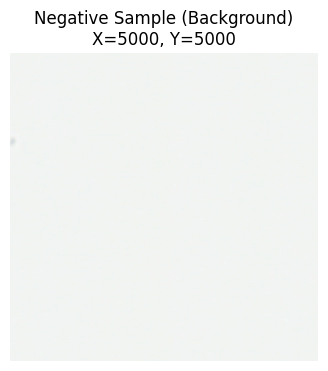

In [8]:
# Select coordinates outside the tissue (background)
x_bg, y_bg = 5000, 5000 
patch_size = (512, 512)

# Extract background patch
patch_bg = slide.read_region((x_bg, y_bg), 0, patch_size).convert("RGB")

# Visualize background patch
plt.figure(figsize=(4, 4))
plt.imshow(patch_bg)
plt.title(f"Negative Sample (Background)\nX={x_bg}, Y={y_bg}")
plt.axis("off")
plt.show()

### First Glomerulus Extraction

Bounding Box Coordinates: Start X=4104, Start Y=45561, Dim=3547x3410


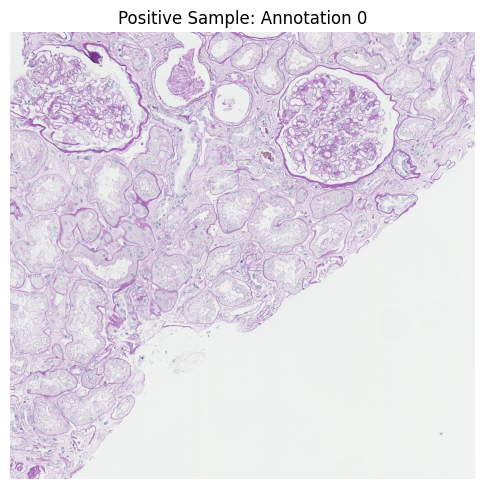

In [9]:
# Parse the XML file
tree = ET.parse(xml_path)
root = tree.getroot()

# Get the first annotation
first_annotation = root.find('.//Annotation')
annotation_name = first_annotation.get('Name')

# Extract X and Y coordinates
x_coords = [float(coord.get('X')) for coord in first_annotation.findall('.//Coordinate')]
y_coords = [float(coord.get('Y')) for coord in first_annotation.findall('.//Coordinate')]

# Calculate the Bounding Box with a safety margin
margin = 50
start_x = int(min(x_coords)) - margin
start_y = int(min(y_coords)) - margin
width = int(max(x_coords) - min(x_coords)) + (margin * 50)
height = int(max(y_coords) - min(y_coords)) + (margin * 50)

print(f"Bounding Box Coordinates: Start X={start_x}, Start Y={start_y}, Dim={width}x{height}")

# Extract glomerulus patch
glomerulus_patch = slide.read_region((start_x, start_y), 0, (width, height)).convert("RGB")

# Visualize positive patch
plt.figure(figsize=(6, 6))
plt.imshow(glomerulus_patch)
plt.title(f"Positive Sample: {annotation_name}")
plt.axis("off")
plt.show()

### Dataset creation

In [16]:
import os
import random
import openslide
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw, ImageStat
import numpy as np

# --- SETTINGS ---
dataset_dir = "./glomeruli_grading/"
images_dir = "./dataset_glomeruli_all/new_images"
masks_dir = "./dataset_glomeruli_all/new_masks"

os.makedirs(images_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

TARGET_SIZE = (512, 512)
MARGIN = 50
NEGATIVE_SAMPLES_PER_WSI = 10 # Quanti sfondi estrarre per ogni WSI

# --- FUNZIONE DI RESIZE & PADDING (adattata per Immagine E Maschera) ---
def resize_and_pad(img, mask, expected_size):
    """
    Fa il resize mantenendo l'aspect ratio e pad a (512, 512).
    L'immagine ha pad BIANCO, la maschera ha pad NERO.
    """
    # 1. Calcola il ratio per il resize
    img.thumbnail(expected_size, Image.Resampling.LANCZOS)
    # Per la maschera usiamo NEAREST per non sfuocare i bordi (deve restare 0 o 255)
    mask.thumbnail(expected_size, Image.Resampling.NEAREST) 
    
    # 2. Crea i background
    bg_img = Image.new("RGB", expected_size, (255, 255, 255)) # Bianco per l'istologia
    bg_mask = Image.new("L", expected_size, 0)                # Nero per la maschera
    
    # 3. Calcola l'offset per centrare
    offset_x = (expected_size[0] - img.size[0]) // 2
    offset_y = (expected_size[1] - img.size[1]) // 2
    
    # 4. Incolla
    bg_img.paste(img, (offset_x, offset_y))
    bg_mask.paste(mask, (offset_x, offset_y))
    
    return bg_img, bg_mask

# --- ESECUZIONE PRINCIPALE ---
total_positives = 0
total_negatives = 0

for file_name in os.listdir(dataset_dir):
    if file_name.endswith(".svs"):
        wsi_path = os.path.join(dataset_dir, file_name)
        xml_name = file_name.replace(".svs", ".xml")
        xml_path = os.path.join(dataset_dir, xml_name)
        base_wsi_name = file_name.replace(".svs", "")
        
        if not os.path.exists(xml_path):
            continue
            
        print(f"Processing WSI: {file_name}")
        
        try:
            slide = openslide.OpenSlide(wsi_path)
            wsi_w, wsi_h = slide.dimensions
            tree = ET.parse(xml_path)
            root = tree.getroot()
        except Exception as e:
            print(f"ERROR reading {file_name}: {e}")
            continue
            
        all_annotations = root.findall('.//Annotation')
        used_boxes = [] # Salvo i box per non sovrapporre i negative samples
        
        # ----------------------------------------------------
        # 1. ESTRAZIONE POSITIVE SAMPLES (GLOMERULI)
        # ----------------------------------------------------
        for annotation in all_annotations:
            annotation_name = annotation.get('Name')
            coordinates = annotation.findall('.//Coordinate')
            
            if len(coordinates) < 3: continue
                
            x_coords = [float(coord.get('X')) for coord in coordinates]
            y_coords = [float(coord.get('Y')) for coord in coordinates]
            
            # Bounding box con margine CORRETTO (+ margin*2)
            start_x = max(0, int(min(x_coords)) - MARGIN)
            start_y = max(0, int(min(y_coords)) - MARGIN)
            width = int(max(x_coords) - min(x_coords)) + (MARGIN * 2)
            height = int(max(y_coords) - min(y_coords)) + (MARGIN * 2)
            
            used_boxes.append((start_x, start_y, start_x+width, start_y+height))
            
            # Estrai immagine raw
            try:
                raw_patch = slide.read_region((start_x, start_y), 0, (width, height)).convert("RGB")
            except:
                continue
                
            # Disegna maschera raw
            local_polygon = [(x - start_x, y - start_y) for x, y in zip(x_coords, y_coords)]
            raw_mask = Image.new('L', (width, height), 0)
            ImageDraw.Draw(raw_mask).polygon(local_polygon, outline=255, fill=255)
            
            # APPLICA LA TUA LOGICA DI RESIZE & PADDING SU ENTRAMBI
            final_img, final_mask = resize_and_pad(raw_patch, raw_mask, TARGET_SIZE)
            
            # Salva
            clean_name = annotation_name.replace(" ", "_")
            final_img.save(os.path.join(images_dir, f"{base_wsi_name}_{clean_name}.png"))
            final_mask.save(os.path.join(masks_dir, f"{base_wsi_name}_{clean_name}.png"))
            total_positives += 1
            
        # ----------------------------------------------------
        # 2. ESTRAZIONE NEGATIVE SAMPLES (RAPPORTO 1:1, MIX TESSUTO/VETRINO)
        # ----------------------------------------------------
        for (bx1, by1, bx2, by2) in used_boxes:
            neg_for_this_glomerulus = 0
            attempts = 0
            
            center_x = (bx1 + bx2) // 2
            center_y = (by1 + by2) // 2
            
            # Vogliamo ESATTAMENTE 1 negativo per ogni glomerulo (Rapporto 1:1)
            while neg_for_this_glomerulus < 1 and attempts < 20:
                attempts += 1
                
                offset_x = random.choice([random.randint(-1500, -300), random.randint(300, 1500)])
                offset_y = random.choice([random.randint(-1500, -300), random.randint(300, 1500)])
                
                rand_x = max(0, min(center_x + offset_x, wsi_w - TARGET_SIZE[0]))
                rand_y = max(0, min(center_y + offset_y, wsi_h - TARGET_SIZE[1]))
                
                # 1. CONTROLLO SOVRAPPOSIZIONE
                overlap = False
                for (ox1, oy1, ox2, oy2) in used_boxes:
                    if not (rand_x + TARGET_SIZE[0] < ox1 or rand_x > ox2 or 
                            rand_y + TARGET_SIZE[1] < oy1 or rand_y > oy2):
                        overlap = True
                        break
                
                if overlap:
                    continue 
                
                # 2. ESTRAZIONE E CONTROLLO VETRINO (Accettiamo il 20% di immagini bianche)
                bg_patch = slide.read_region((rand_x, rand_y), 0, TARGET_SIZE).convert("RGB")
                gray_patch = bg_patch.convert("L")
                mean_brightness = ImageStat.Stat(gray_patch).mean[0]
                
                # Se è vetrino bianco (> 225), lo scartiamo l'80% delle volte. 
                # Il 40% delle volte lo teniamo 
                if mean_brightness > 225 and random.random() > 0.40:
                    continue 
                    
                # Salvataggio
                bg_mask = Image.new('L', TARGET_SIZE, 0)
                
                bg_patch.save(os.path.join(images_dir, f"{base_wsi_name}_neg_{total_negatives}.png"))
                bg_mask.save(os.path.join(masks_dir, f"{base_wsi_name}_neg_{total_negatives}.png"))
                
                neg_for_this_glomerulus += 1
                total_negatives += 1

        slide.close()

print(f"\nPROCESS COMPLETE!")
print(f"Glomeruli (Positives): {total_positives}")
print(f"Hard Backgrounds (Tissue Negatives): {total_negatives}")

Processing WSI: RECHERCHE-009.svs
Processing WSI: RECHERCHE-004.svs
Processing WSI: RECHERCHE-010.svs
Processing WSI: RECHERCHE-011.svs
Processing WSI: RECHERCHE-005.svs
Processing WSI: RECHERCHE-015.svs
Processing WSI: RECHERCHE-003.svs

PROCESS COMPLETE!
Glomeruli (Positives): 567
Hard Backgrounds (Tissue Negatives): 567
